# 📉 Infosys Margin Diagnosis: Why Growth Didn't Translate to Profitability

### Data Analysis & Financial Margin Diagnosis

This notebook analyzes Infosys' annual financial performance from FY17 to FY26 to understand why Operating Profit Margin declined despite consistent sales growth.

The analysis focuses on:
- Sales growth and Operating Profit Margin (OPM)
- Cost structure as a percentage of Sales
- Quantifying the contribution of individual cost drivers to OPM change
- Benchmarking Infosys against TCS and Wipro

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../Data/infosys_annual_clean.csv")

df.head()

,FY,Sales,Power and Fuel,Other Mfr. Exp,Employee Cost,Selling and admin,Other Expenses,Other Income,Depreciation,Interest,...,Total Expenses,Operating Profit,OPM %,Power and Fuel % of Sales,Other Mfr. Exp % of Sales,Employee Cost % of Sales,Selling and admin % of Sales,Other Expenses % of Sales,Sales YoY %,Net Margin %
0,FY17,68484,228,6712,37669,4584,687,3050,1703,NaN,...,49880,18604,27.17,0.33,9.80,55.00,6.69,1.00,NaN,20.96
1,FY18,70522,207,7286,38902,4585,720,3311,1863,NaN,...,51700,18822,26.69,0.29,10.33,55.16,6.50,1.02,2.98,22.73
2,FY19,82675,221,9902,45323,5553,1506,2882,2011,NaN,...,62505,20170,24.40,0.27,11.98,54.82,6.72,1.82,17.23,18.63
3,FY20,90791,229,11086,50895,5375,939,2803,2893,170.0,...,68524,22267,24.53,0.25,12.21,56.06,5.92,1.03,9.82,18.28
4,FY21,100472,143,12800,55547,3194,899,2201,3267,195.0,...,72583,27889,27.76,0.14,12.74,55.29,3.18,0.89,10.66,19.26


## 🔍 Data Understanding

The cleaned Infosys dataset contains annual financial data from FY17 to FY26.

The analysis focuses on:
- Sales
- Operating Profit Margin (OPM)
- Employee Cost
- Other Manufacturing Expenses
- Selling & Administration expenses
- Other Expenses
- Power & Fuel
- Net Profit

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   FY                            10 non-null     object 
 1   Sales                         10 non-null     int64  
 2   Power and Fuel                10 non-null     int64  
 3   Other Mfr. Exp                10 non-null     int64  
 4   Employee Cost                 10 non-null     int64  
 5   Selling and admin             10 non-null     int64  
 6   Other Expenses                10 non-null     int64  
 7   Other Income                  10 non-null     int64  
 8   Depreciation                  10 non-null     int64  
 9   Interest                      7 non-null      float64
 10  Profit before tax             10 non-null     int64  
 11  Tax                           10 non-null     int64  
 12  Net profit                    10 non-null     int64  
 13  Dividend

In [4]:
print("Rows, Columns:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Rows, Columns: (10, 24)

Columns:
['FY', 'Sales', 'Power and Fuel', 'Other Mfr. Exp', 'Employee Cost', 'Selling and admin', 'Other Expenses', 'Other Income', 'Depreciation', 'Interest', 'Profit before tax', 'Tax', 'Net profit', 'Dividend Amount', 'Total Expenses', 'Operating Profit', 'OPM %', 'Power and Fuel % of Sales', 'Other Mfr. Exp % of Sales', 'Employee Cost % of Sales', 'Selling and admin % of Sales', 'Other Expenses % of Sales', 'Sales YoY %', 'Net Margin %']


In [5]:
df.isnull().sum()

FY                              0
Sales                           0
Power and Fuel                  0
Other Mfr. Exp                  0
Employee Cost                   0
Selling and admin               0
Other Expenses                  0
Other Income                    0
Depreciation                    0
Interest                        3
Profit before tax               0
Tax                             0
Net profit                      0
Dividend Amount                 0
Total Expenses                  0
Operating Profit                0
OPM %                           0
Power and Fuel % of Sales       0
Other Mfr. Exp % of Sales       0
Employee Cost % of Sales        0
Selling and admin % of Sales    0
Other Expenses % of Sales       0
Sales YoY %                     1
Net Margin %                    0
dtype: int64

In [6]:
df[df.isnull().any(axis=1)]

,FY,Sales,Power and Fuel,Other Mfr. Exp,Employee Cost,Selling and admin,Other Expenses,Other Income,Depreciation,Interest,...,Total Expenses,Operating Profit,OPM %,Power and Fuel % of Sales,Other Mfr. Exp % of Sales,Employee Cost % of Sales,Selling and admin % of Sales,Other Expenses % of Sales,Sales YoY %,Net Margin %
0,FY17,68484,228,6712,37669,4584,687,3050,1703,NaN,...,49880,18604,27.17,0.33,9.80,55.00,6.69,1.00,NaN,20.96
1,FY18,70522,207,7286,38902,4585,720,3311,1863,NaN,...,51700,18822,26.69,0.29,10.33,55.16,6.50,1.02,2.98,22.73
2,FY19,82675,221,9902,45323,5553,1506,2882,2011,NaN,...,62505,20170,24.40,0.27,11.98,54.82,6.72,1.82,17.23,18.63


In [7]:
df.isnull().sum()[df.isnull().sum() > 0]

Interest       3
Sales YoY %    1
dtype: int64

In [8]:
df["Sales YoY"] = df["Sales"].pct_change() * 100

df[["FY", "Sales", "Sales YoY"]]

,FY,Sales,Sales YoY
0,FY17,68484,NaN
1,FY18,70522,2.975878
2,FY19,82675,17.232920
3,FY20,90791,9.816752
4,FY21,100472,10.662951
5,FY22,121641,21.069552
6,FY23,146767,20.655864
7,FY24,153670,4.703373
8,FY25,162990,6.064944
9,FY26,178650,9.607951


In [9]:
df[["FY", "Sales", "Sales YoY"]].head()

,FY,Sales,Sales YoY
0,FY17,68484,NaN
1,FY18,70522,2.975878
2,FY19,82675,17.232920
3,FY20,90791,9.816752
4,FY21,100472,10.662951


In [10]:
# Key financial metrics

df["OPM (%)"] = (df["Operating Profit"] / df["Sales"]) * 100

df["Employee Cost %"] = (df["Employee Cost"] / df["Sales"]) * 100
df["Other Mfr. Exp %"] = (df["Other Mfr. Exp"] / df["Sales"]) * 100
df["Selling & Admin %"] = (df["Selling and admin"] / df["Sales"]) * 100
df["Other Expenses %"] = (df["Other Expenses"] / df["Sales"]) * 100
df["Power & Fuel %"] = (df["Power and Fuel"] / df["Sales"]) * 100

df[[
    "FY",
    "Sales",
    "OPM (%)",
    "Employee Cost %",
    "Other Mfr. Exp %",
    "Selling & Admin %",
    "Other Expenses %",
    "Power & Fuel %"
]]

,FY,Sales,OPM (%),Employee Cost %,Other Mfr. Exp %,Selling & Admin %,Other Expenses %,Power & Fuel %
0,FY17,68484,27.165469,55.004089,9.800829,6.693534,1.003154,0.332924
1,FY18,70522,26.689544,55.162928,10.331528,6.501517,1.020958,0.293525
2,FY19,82675,24.396734,54.820683,11.977018,6.716662,1.821591,0.267312
3,FY20,90791,24.525559,56.057318,12.210461,5.920190,1.034243,0.252228
4,FY21,100472,27.757982,55.286050,12.739868,3.178995,0.894777,0.142328
5,FY22,121641,25.888475,52.611373,17.009068,3.539103,0.843466,0.108516
6,FY23,146767,23.935898,53.400288,17.940000,3.611166,0.992730,0.119918
7,FY24,153670,23.703390,53.774972,17.697013,3.712501,0.982625,0.129498
8,FY25,162990,24.072642,52.744340,18.648383,3.705135,0.693294,0.136205
9,FY26,178650,23.666387,53.239295,18.428212,3.797369,0.743913,0.124825


In [11]:
sales_start = df.loc[df["FY"] == "FY17", "Sales"].iloc[0]
sales_end = df.loc[df["FY"] == "FY26", "Sales"].iloc[0]

years = 9

sales_cagr = ((sales_end / sales_start) ** (1 / years) - 1) * 100

print(f"Sales CAGR (FY17–FY26): {sales_cagr:.2f}%")

Sales CAGR (FY17–FY26): 11.24%


In [12]:
peak_opm_row = df.loc[df["OPM (%)"].idxmax()]

print("Peak OPM:")
print(f"FY: {peak_opm_row['FY']}")
print(f"OPM: {peak_opm_row['OPM (%)']:.2f}%")

Peak OPM:
FY: FY21
OPM: 27.76%


In [13]:
peak_opm = df["OPM (%)"].max()
fy26_opm = df.loc[df["FY"] == "FY26", "OPM (%)"].iloc[0]

opm_change = fy26_opm - peak_opm

print(f"Peak OPM: {peak_opm:.2f}%")
print(f"FY26 OPM: {fy26_opm:.2f}%")
print(f"OPM Change Since Peak: {opm_change:.2f} pp")

Peak OPM: 27.76%
FY26 OPM: 23.67%
OPM Change Since Peak: -4.09 pp


In [14]:
cost_columns = [
    "Employee Cost %",
    "Other Mfr. Exp %",
    "Selling & Admin %",
    "Other Expenses %",
    "Power & Fuel %"
]

cost_structure = df[["FY"] + cost_columns].copy()

cost_structure

,FY,Employee Cost %,Other Mfr. Exp %,Selling & Admin %,Other Expenses %,Power & Fuel %
0,FY17,55.004089,9.800829,6.693534,1.003154,0.332924
1,FY18,55.162928,10.331528,6.501517,1.020958,0.293525
2,FY19,54.820683,11.977018,6.716662,1.821591,0.267312
3,FY20,56.057318,12.210461,5.920190,1.034243,0.252228
4,FY21,55.286050,12.739868,3.178995,0.894777,0.142328
5,FY22,52.611373,17.009068,3.539103,0.843466,0.108516
6,FY23,53.400288,17.940000,3.611166,0.992730,0.119918
7,FY24,53.774972,17.697013,3.712501,0.982625,0.129498
8,FY25,52.744340,18.648383,3.705135,0.693294,0.136205
9,FY26,53.239295,18.428212,3.797369,0.743913,0.124825


In [15]:
fy21 = df[df["FY"] == "FY21"].iloc[0]
fy26 = df[df["FY"] == "FY26"].iloc[0]

driver_changes = pd.DataFrame({
    "Cost Driver": [
        "Employee Cost",
        "Other Mfr. Expenses",
        "Selling & Admin",
        "Other Expenses",
        "Power & Fuel"
    ],
    "FY21 %": [
        fy21["Employee Cost %"],
        fy21["Other Mfr. Exp %"],
        fy21["Selling & Admin %"],
        fy21["Other Expenses %"],
        fy21["Power & Fuel %"]
    ],
    "FY26 %": [
        fy26["Employee Cost %"],
        fy26["Other Mfr. Exp %"],
        fy26["Selling & Admin %"],
        fy26["Other Expenses %"],
        fy26["Power & Fuel %"]
    ]
})

driver_changes["Change (pp)"] = (
    driver_changes["FY26 %"] - driver_changes["FY21 %"]
)

driver_changes

,Cost Driver,FY21 %,FY26 %,Change (pp)
0,Employee Cost,55.286050,53.239295,-2.046755
1,Other Mfr. Expenses,12.739868,18.428212,5.688344
2,Selling & Admin,3.178995,3.797369,0.618374
3,Other Expenses,0.894777,0.743913,-0.150864
4,Power & Fuel,0.142328,0.124825,-0.017503


In [16]:
driver_changes["OPM Impact (pp)"] = -driver_changes["Change (pp)"]

driver_changes

,Cost Driver,FY21 %,FY26 %,Change (pp),OPM Impact (pp)
0,Employee Cost,55.286050,53.239295,-2.046755,2.046755
1,Other Mfr. Expenses,12.739868,18.428212,5.688344,-5.688344
2,Selling & Admin,3.178995,3.797369,0.618374,-0.618374
3,Other Expenses,0.894777,0.743913,-0.150864,0.150864
4,Power & Fuel,0.142328,0.124825,-0.017503,0.017503


In [17]:
total_driver_impact = driver_changes["OPM Impact (pp)"].sum()

print(f"Total Cost Driver Impact: {total_driver_impact:.2f} pp")
print(f"Actual OPM Change: {opm_change:.2f} pp")
print(f"Difference: {total_driver_impact - opm_change:.2f} pp")

Total Cost Driver Impact: -4.09 pp
Actual OPM Change: -4.09 pp
Difference: 0.00 pp


In [18]:
summary_table = driver_changes[
    ["Cost Driver", "FY21 %", "FY26 %", "Change (pp)", "OPM Impact (pp)"]
].copy()

summary_table.round(2)

,Cost Driver,FY21 %,FY26 %,Change (pp),OPM Impact (pp)
0,Employee Cost,55.29,53.24,-2.05,2.05
1,Other Mfr. Expenses,12.74,18.43,5.69,-5.69
2,Selling & Admin,3.18,3.80,0.62,-0.62
3,Other Expenses,0.89,0.74,-0.15,0.15
4,Power & Fuel,0.14,0.12,-0.02,0.02


## 📊 Exploratory Data Analysis

### Sales Growth vs Operating Margin

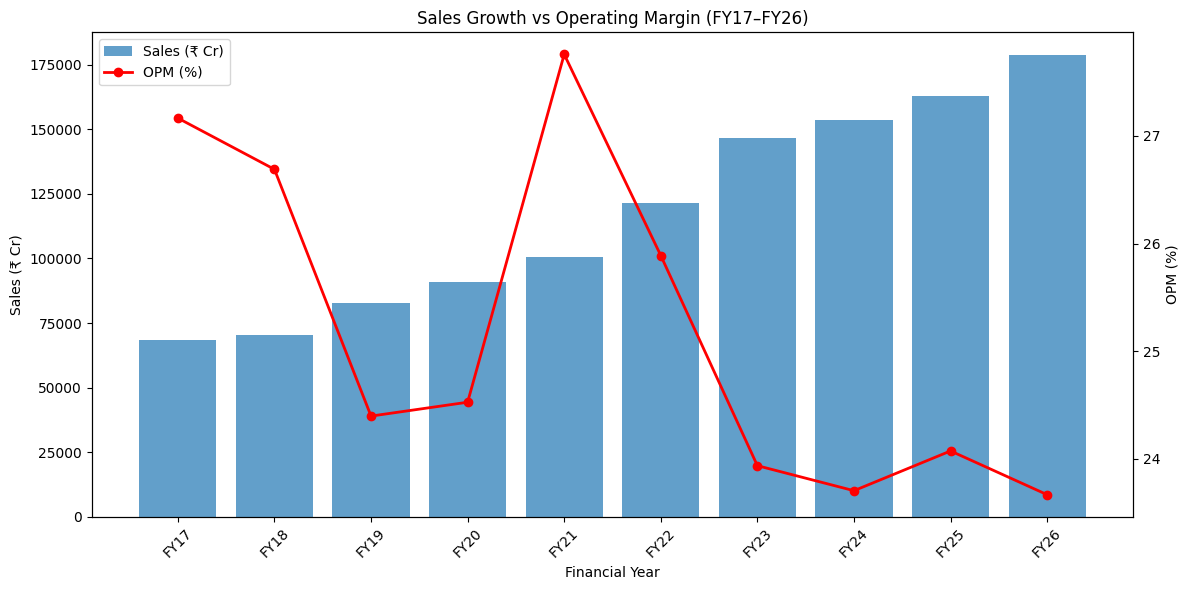

In [19]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Sales — bars
bars = ax1.bar(
    df["FY"],
    df["Sales"],
    alpha=0.7,
    label="Sales (₹ Cr)"
)

ax1.set_xlabel("Financial Year")
ax1.set_ylabel("Sales (₹ Cr)")
ax1.tick_params(axis="x", rotation=45)

# OPM — line
ax2 = ax1.twinx()

line = ax2.plot(
    df["FY"],
    df["OPM (%)"],
    marker="o",
    linewidth=2,
    color="red",
    label="OPM (%)"
)

ax2.set_ylabel("OPM (%)")

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left"
)

plt.title("Sales Growth vs Operating Margin (FY17–FY26)")
plt.tight_layout()
plt.show()

### Cost Structure as % of Sales

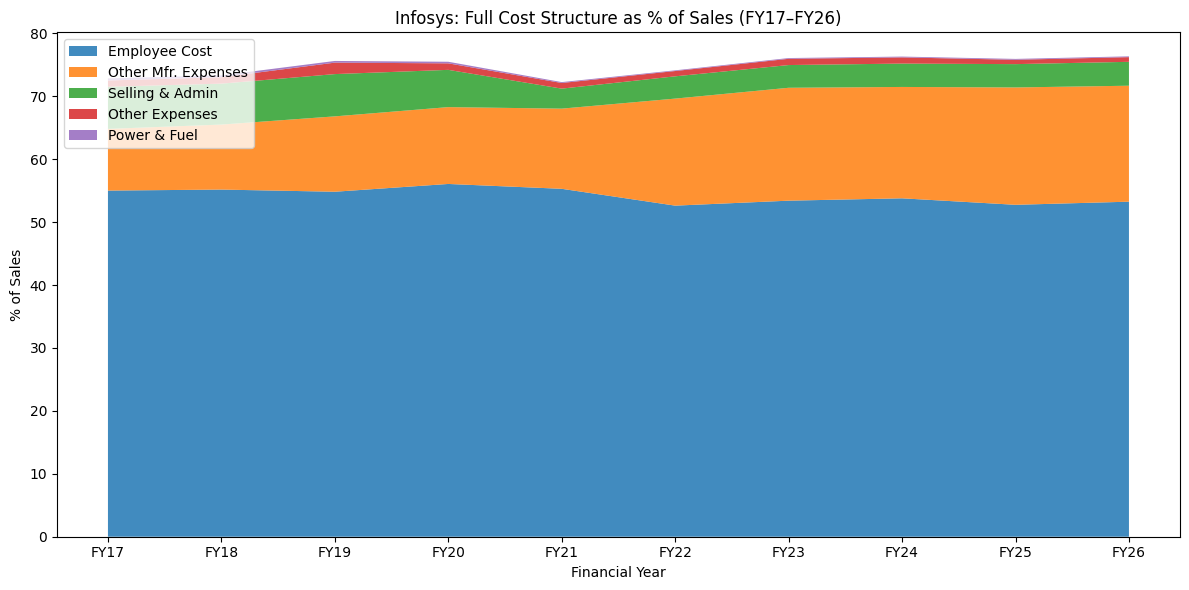

In [20]:
plt.figure(figsize=(12, 6))

plt.stackplot(
    df["FY"],
    df["Employee Cost %"],
    df["Other Mfr. Exp %"],
    df["Selling & Admin %"],
    df["Other Expenses %"],
    df["Power & Fuel %"],
    labels=[
        "Employee Cost",
        "Other Mfr. Expenses",
        "Selling & Admin",
        "Other Expenses",
        "Power & Fuel"
    ],
    alpha=0.85
)

plt.xlabel("Financial Year")
plt.ylabel("% of Sales")
plt.title("Infosys: Full Cost Structure as % of Sales (FY17–FY26)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

### Cost Driver Impact on OPM: FY21 → FY26

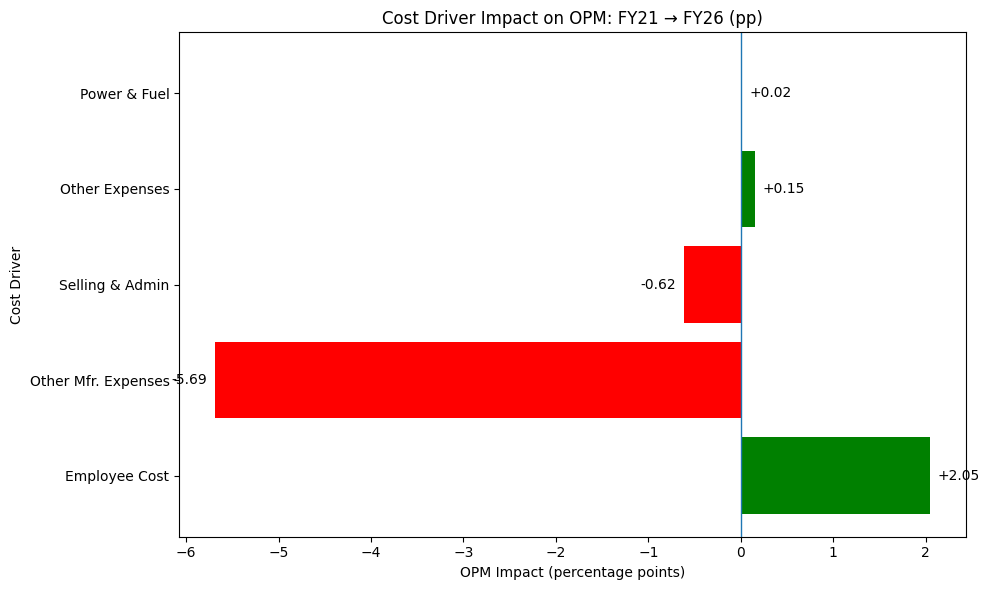

In [21]:
plt.figure(figsize=(10, 6))

colors = [
    "green" if value >= 0 else "red"
    for value in driver_changes["OPM Impact (pp)"]
]

bars = plt.barh(
    driver_changes["Cost Driver"],
    driver_changes["OPM Impact (pp)"],
    color=colors
)

plt.axvline(0, linewidth=1)
plt.xlabel("OPM Impact (percentage points)")
plt.ylabel("Cost Driver")
plt.title("Cost Driver Impact on OPM: FY21 → FY26 (pp)")

# Add values to bars
for bar, value in zip(bars, driver_changes["OPM Impact (pp)"]):
    plt.text(
        value + (0.08 if value >= 0 else -0.08),
        bar.get_y() + bar.get_height() / 2,
        f"{value:+.2f}",
        va="center",
        ha="left" if value >= 0 else "right"
    )

plt.tight_layout()
plt.show()

## 🏢 Sector Benchmarking

### Infosys vs TCS vs Wipro

In [22]:
sector_df = pd.read_csv("../Data/sector_opm_comparison.csv")

sector_df.head()

,FY,Company,OPM %
0,FY17,Infosys,27.17
1,FY18,Infosys,26.69
2,FY19,Infosys,24.40
3,FY20,Infosys,24.53
4,FY21,Infosys,27.76


In [23]:
print("Rows, Columns:", sector_df.shape)

print("\nColumns:")
print(sector_df.columns.tolist())

Rows, Columns: (30, 3)

Columns:
['FY', 'Company', 'OPM %']


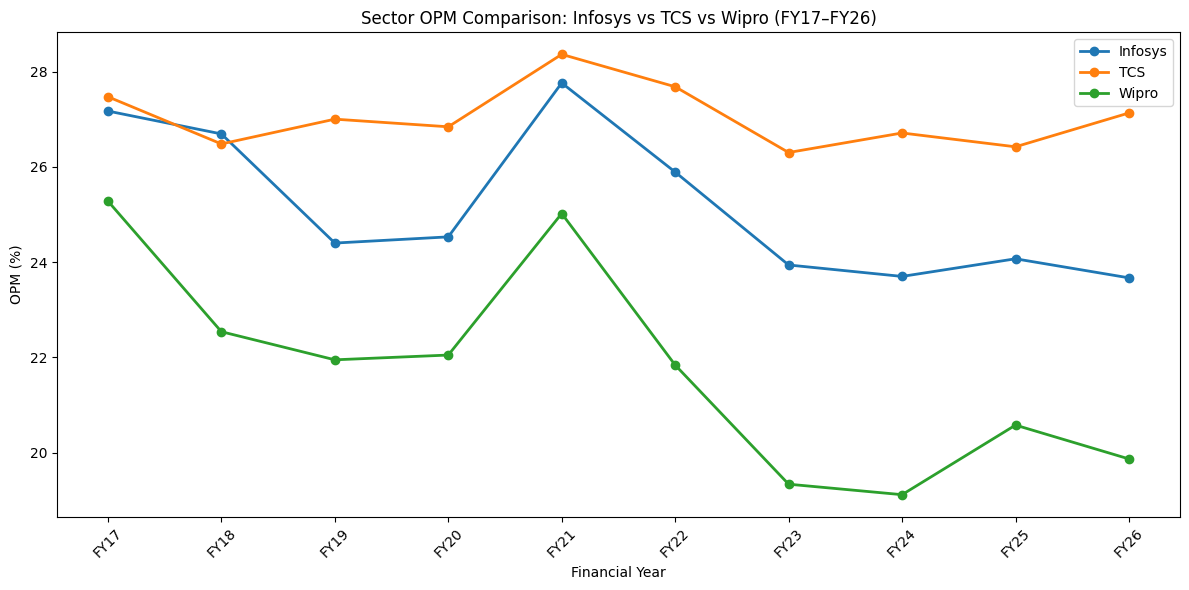

In [24]:
sector_df["OPM %"] = pd.to_numeric(sector_df["OPM %"], errors="coerce")

plt.figure(figsize=(12, 6))

for company in sector_df["Company"].unique():
    company_data = sector_df[sector_df["Company"] == company]

    plt.plot(
        company_data["FY"],
        company_data["OPM %"],
        marker="o",
        linewidth=2,
        label=company
    )

plt.xlabel("Financial Year")
plt.ylabel("OPM (%)")
plt.title("Sector OPM Comparison: Infosys vs TCS vs Wipro (FY17–FY26)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.savefig(
    "../Outputs/chart4_sector_opm_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
benchmark = sector_df[sector_df["FY"].isin(["FY21", "FY26"])].pivot(
    index="Company",
    columns="FY",
    values="OPM %"
).reset_index()

benchmark["OPM Change (pp)"] = benchmark["FY26"] - benchmark["FY21"]

benchmark.round(2)

FY,Company,FY21,FY26,OPM Change (pp)
0,Infosys,27.76,23.67,-4.09
1,TCS,28.36,27.13,-1.23
2,Wipro,25.02,19.87,-5.15


## 💡 Key Findings

1. **Revenue Growth:** Sales grew at a CAGR of 11.24% from FY17 to FY26.

2. **Margin Decline:** OPM declined by 4.09 percentage points from its FY21 peak of 27.76% to 23.67% in FY26.

3. **Largest Negative Driver:** Other Manufacturing Expenses increased from 12.74% to 18.43% of Sales, creating 5.69 percentage points of negative pressure on OPM.

4. **Employee Cost Efficiency:** Employee Cost decreased from 55.29% to 53.24% of Sales, partially offsetting the margin pressure by 2.05 percentage points.

5. **Peer Benchmarking:** From FY21 to FY26, OPM declined by 1.23 pp for TCS, 4.09 pp for Infosys, and 5.15 pp for Wipro.

## 📌 Project Conclusion

Infosys achieved consistent revenue growth during FY17–FY26, with Sales growing at a CAGR of 11.24%. However, Operating Profit Margin declined by 4.09 percentage points from its FY21 peak to FY26.

The cost-driver analysis identifies Other Manufacturing Expenses as the largest negative contributor, increasing from 12.74% to 18.43% of Sales. Lower Employee Cost as a percentage of Sales partially offset this pressure.

The peer comparison provides additional context for Infosys' margin trend relative to TCS and Wipro.

**Business implication:** Management should investigate the underlying components of Other Manufacturing Expenses, identify the operational factors driving the increase, and evaluate targeted cost-control opportunities while sustaining revenue growth.